# Superstore Dataset Cleaning

This notebook will demonstrate reading the **Sample - Superstore.csv** file, performing basic cleaning steps and preparing the data for downstream SQL ingestion (e.g. into SQLite, MySQL, PostgreSQL, etc.).  

Cleaning goals:

1. parse dates and enforce proper data types
2. normalize column names (snake_case)
3. handle missing values and duplicates
4. trim whitespace and standardize text fields
5. export cleaned data to CSV or a SQL database

The cleaned table will be easier to query using SQL later on.

In [1]:
import sys
print(sys.executable)

c:\Users\HRUSHI\Desktop\PROJECTS\venv\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Sample_Superstore.csv", encoding="latin1")
print("Shape:", df.shape)
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [6]:
print("\nDuplicates:", df.duplicated().sum())


Duplicates: 0


In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
# string columns
str_cols = df.select_dtypes(include="object").columns
str_cols

C:\Users\HRUSHI\AppData\Local\Temp\ipykernel_12544\202012635.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name'],
      dtype='str')

In [9]:
df[str_cols]= df[str_cols].apply(lambda x: x.str.strip())
print('whitespace removesd')

whitespace removesd


In [10]:
df[str_cols].head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
0,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System


In [11]:
# converting date column to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")

In [12]:
df["Ship Date"] = pd.to_datetime(df['Ship Date'], format ='%m/%d/%Y')

In [13]:
print(df[['Order Date','Ship Date']].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [14]:
# Fixing Postal Code (preserving leading zones)
df['Postal Code'] = df['Postal Code'].astype(str).str.zfill(5)
df['Postal Code'].head()

0    42420
1    42420
2    90036
3    33311
4    33311
Name: Postal Code, dtype: str

In [15]:
#Dropping Columns 
df=df.drop(columns=['Row ID'])


In [16]:
df.columns.tolist()

['Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   str           
 1   Order Date     9994 non-null   datetime64[us]
 2   Ship Date      9994 non-null   datetime64[us]
 3   Ship Mode      9994 non-null   str           
 4   Customer ID    9994 non-null   str           
 5   Customer Name  9994 non-null   str           
 6   Segment        9994 non-null   str           
 7   Country        9994 non-null   str           
 8   City           9994 non-null   str           
 9   State          9994 non-null   str           
 10  Postal Code    9994 non-null   str           
 11  Region         9994 non-null   str           
 12  Product ID     9994 non-null   str           
 13  Category       9994 non-null   str           
 14  Sub-Category   9994 non-null   str           
 15  Product Name   9994 non-null   s

In [18]:
for col in ["Ship Mode", "Segment", "Region", "Category", "Sub-Category"]:
    df[col] = df[col].str.title()
print("Categorical columns standardised.")

Categorical columns standardised.


In [19]:
print(df.columns)

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')


In [20]:
# Add Derived Columns
df["Days_to_Ship"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Days_to_Ship"].value_counts()

Days_to_Ship
4    2774
5    2169
2    1334
6    1203
3    1005
7     621
0     519
1     369
Name: count, dtype: int64

In [21]:
df["Is Loss"]      = df["Profit"] < 0
df["High Discount"] = df["Discount"] > 0.8

In [22]:
# Verify the computed columns are correct
expected_days = (df["Ship Date"] - df["Order Date"]).dt.days
assert expected_days.equals(df["Days_to_Ship"]), "Mismatch in 'Days to Ship' calculation"


In [23]:
# Check dtypes and basic sanity
print("Days to Ship dtype:", df["Days_to_Ship"].dtype)
print("Is Loss dtype:", df["Is Loss"].dtype)
print("High Discount dtype:", df["High Discount"].dtype)

print(df[["Days_to_Ship", "Is Loss", "High Discount"]].head())

Days to Ship dtype: int64
Is Loss dtype: bool
High Discount dtype: bool
   Days_to_Ship  Is Loss  High Discount
0             3    False          False
1             3    False          False
2             4    False          False
3             7     True          False
4             7    False          False


In [24]:
# Sanity checks
print("Any negative shipping days?", (df["Days_to_Ship"] < 0).any())

print("Any missing values in these columns?\n",
      df[["Days_to_Ship","Is Loss","High Discount"]].isnull().sum())

Any negative shipping days? False
Any missing values in these columns?
 Days_to_Ship     0
Is Loss          0
High Discount    0
dtype: int64


In [25]:
# Removing Duplicates
before =len(df)
df=df.drop_duplicates()
print(f"Duplicates removed :{before - len(df)}")

Duplicates removed :1


In [26]:
# Validating Numeric Range
assert (df["Quantity"] > 0).all(),         "Negative/zero quantities found!"
assert df["Discount"].between(0, 1).all(), "Discount out of [0,1] range!"
assert (df["Sales"] >= 0).all(),           "Negative sales found!"
print("All validation checks passed ")

All validation checks passed 


In [32]:
# Summary after cleaning
print("final Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())


final Shape: (9993, 23)

Missing Values:
 Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Days_to_Ship     0
Is Loss          0
High Discount    0
dtype: int64


In [34]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Days_to_Ship,Is Loss,High Discount
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,False,False
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,False,False
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,False,False
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,True,False
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,False,False


In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9993 non-null   str           
 1   Order Date     9993 non-null   datetime64[us]
 2   Ship Date      9993 non-null   datetime64[us]
 3   Ship Mode      9993 non-null   str           
 4   Customer ID    9993 non-null   str           
 5   Customer Name  9993 non-null   str           
 6   Segment        9993 non-null   str           
 7   Country        9993 non-null   str           
 8   City           9993 non-null   str           
 9   State          9993 non-null   str           
 10  Postal Code    9993 non-null   str           
 11  Region         9993 non-null   str           
 12  Product ID     9993 non-null   str           
 13  Category       9993 non-null   str           
 14  Sub-Category   9993 non-null   str           
 15  Product Name   9993 non-null   str   

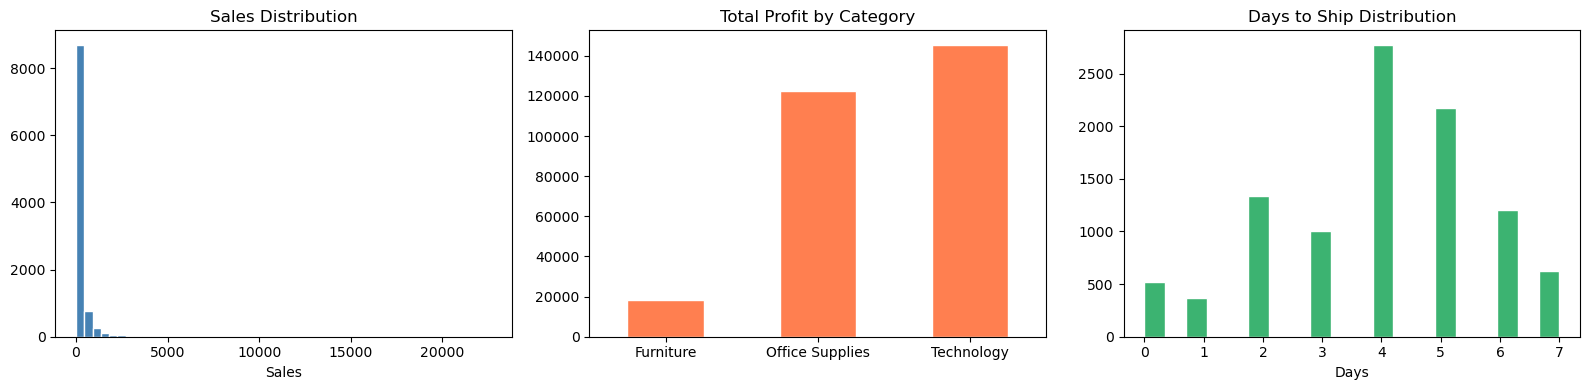

In [29]:
# Visualisations
fig, axes =plt.subplots(1,3,figsize = (16,4))

# Sales distribution
axes[0].hist(df["Sales"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Sales Distribution")
axes[0].set_xlabel("Sales")

# Profit by Category
df.groupby("Category")["Profit"].sum().plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Total Profit by Category")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=0)

# Days to Ship distribution
axes[2].hist(df["Days_to_Ship"], bins=20, color="mediumseagreen", edgecolor="white")
axes[2].set_title("Days to Ship Distribution")
axes[2].set_xlabel("Days")

plt.tight_layout()
plt.show()

## Save Cleaned Data


In [30]:
# Save Cleaned Data
#df.to_csv("Sample_Superstore_Cleaned.csv", index=False)

#print("Saved → Sample_Superstore_Cleaned.csv")


---
# Exploratory Data Analysis & Visualizations

Now that the data is cleaned, we move on to **14 visualizations** covering:
- Sales Performance
- Product Analytics
- Customer Behaviour
- Shipping & Operations
- Geographic Insights
- Advanced Analytics (Window-function equivalents)

Each chart mirrors the SQL analytics queries written for the PostgreSQL layer of this project.

In [37]:
# ── Visualization Setup ───────────────────────────────────────────────────────
import matplotlib.ticker as mticker
from textwrap import fill

# Rename column for consistency with SQL schema
#df = df.rename(columns={"Days to Ship": "Days_to_Ship"})

# Add helper columns for time-series charts
df["Year"]      = df["Order Date"].dt.year
df["YearMonth"] = df["Order Date"].dt.to_period("M")

# Global style
sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = ["#2563EB", "#10B981", "#F59E0B", "#EF4444", "#8B5CF6", "#EC4899"]
sns.set_palette(PALETTE)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print(f"Ready for visualization: {len(df):,} rows | {df['Order ID'].nunique():,} orders | {df['Year'].min()}–{df['Year'].max()}")

Ready for visualization: 9,993 rows | 5,009 orders | 2014–2017


---
## Section 1 — Sales Performance

### 1.1  Yearly Sales vs Profit with Profit Margin

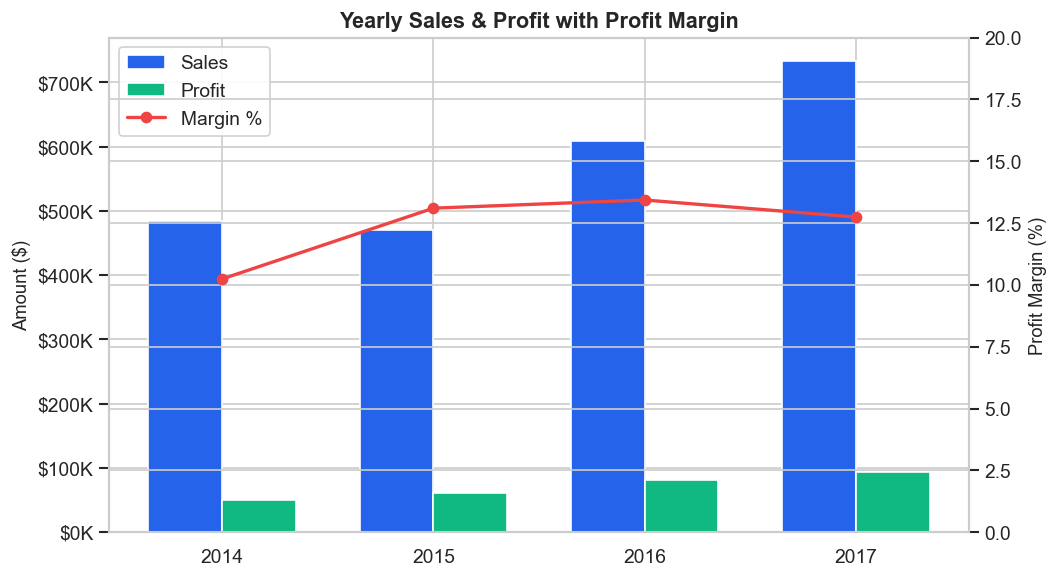

In [39]:
yearly = df.groupby("Year").agg(
    total_sales  = ("Sales",  "sum"),
    total_profit = ("Profit", "sum"),
    total_orders = ("Order ID", "nunique")
).reset_index()
yearly["margin_pct"] = (yearly["total_profit"] / yearly["total_sales"] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(9, 5))
x = np.arange(len(yearly))
w = 0.35

bars1 = ax1.bar(x - w/2, yearly["total_sales"],  w, label="Sales",  color=PALETTE[0], zorder=3)
bars2 = ax1.bar(x + w/2, yearly["total_profit"], w, label="Profit", color=PALETTE[1], zorder=3)
ax1.set_xticks(x)
ax1.set_xticklabels(yearly["Year"].astype(int))
ax1.set_ylabel("Amount ($)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
ax1.set_title("Yearly Sales & Profit with Profit Margin")

ax2 = ax1.twinx()
ax2.plot(x, yearly["margin_pct"], color=PALETTE[3], marker="o", linewidth=2, label="Margin %")
ax2.set_ylabel("Profit Margin (%)")
ax2.set_ylim(0, 20)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.show()




💡Insight: Sales grew steadily year-over-year, with 2017 being the strongest year. 

   Profit margin stayed in the 10.2%–13.4% range.

### 1.2  Monthly Sales Trend

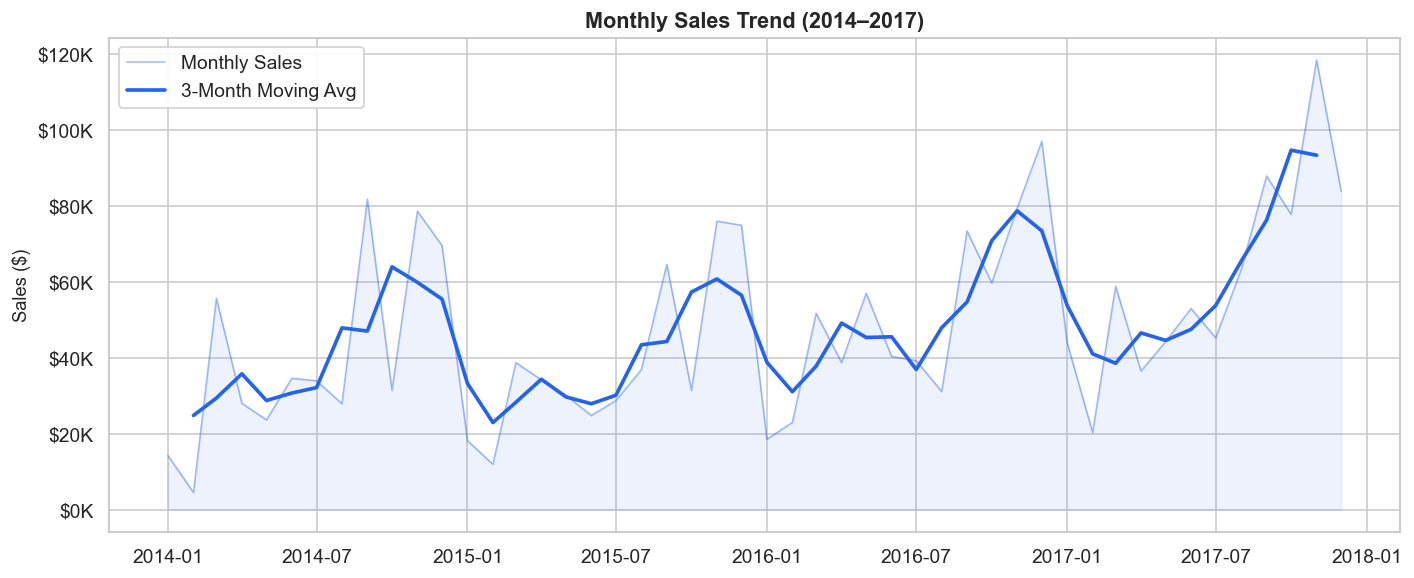

In [40]:
monthly = df.groupby("YearMonth").agg(
    sales  = ("Sales",  "sum"),
    profit = ("Profit", "sum")
).reset_index()
monthly["date"] = monthly["YearMonth"].dt.to_timestamp()
monthly["sales_ma3"] = monthly["sales"].rolling(3, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["date"], monthly["sales"],    color=PALETTE[0], alpha=0.4, linewidth=1, label="Monthly Sales")
ax.plot(monthly["date"], monthly["sales_ma3"], color=PALETTE[0], linewidth=2.2, label="3-Month Moving Avg")
ax.fill_between(monthly["date"], monthly["sales"], alpha=0.08, color=PALETTE[0])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
ax.set_title("Monthly Sales Trend (2014–2017)")
ax.set_xlabel("")
ax.set_ylabel("Sales ($)")
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.show()



In [41]:
print("\n💡 Insight: Clear seasonality — sales spike in Nov-Dec each year (holiday season).")
print("   The upward trend confirms year-over-year growth.")


💡 Insight: Clear seasonality — sales spike in Nov-Dec each year (holiday season).
   The upward trend confirms year-over-year growth.


### 1.3  Sales by Region

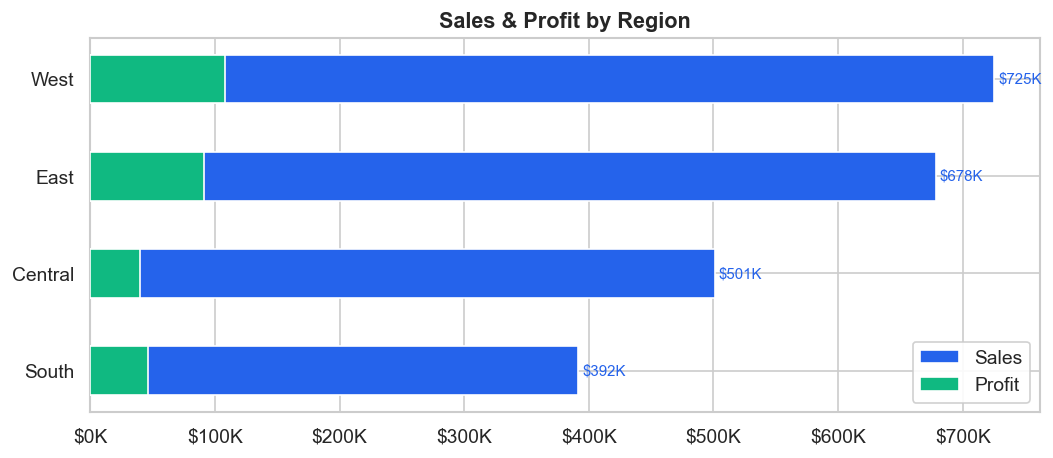

In [42]:
region = df.groupby("Region").agg(
    total_sales  = ("Sales",  "sum"),
    total_profit = ("Profit", "sum")
).sort_values("total_sales", ascending=True).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(region["Region"], region["total_sales"],  color=PALETTE[0], label="Sales",  height=0.5, zorder=3)
ax.barh(region["Region"], region["total_profit"], color=PALETTE[1], label="Profit", height=0.5, zorder=4)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
ax.set_title("Sales & Profit by Region")
ax.legend(framealpha=0.9)

# Add value labels
for i, row in region.iterrows():
    ax.text(row["total_sales"] + 3000, row["Region"], f"${row['total_sales']/1000:,.0f}K",
            va="center", fontsize=9, color=PALETTE[0])

plt.tight_layout()
plt.show()


In [43]:

print("\n💡 Insight: West leads in sales, but Central has notably lower profit relative to sales — worth investigating.")


💡 Insight: West leads in sales, but Central has notably lower profit relative to sales — worth investigating.


### 1.4  Sales by Customer Segment

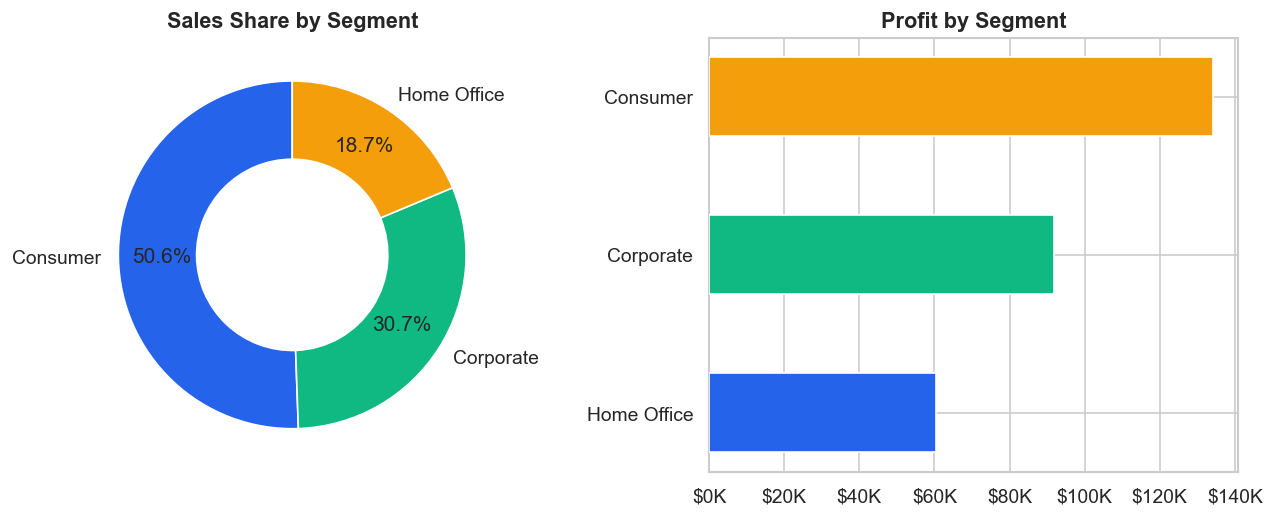


💡 Insight: Consumer segment drives ~50% of sales. All three segments are profitable.


In [44]:
segment = df.groupby("Segment").agg(
    total_sales  = ("Sales",  "sum"),
    total_profit = ("Profit", "sum"),
    customers    = ("Customer ID", "nunique")
).reset_index()

seg_colors = [PALETTE[0], PALETTE[1], PALETTE[2]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Donut chart
wedges, texts, autotexts = ax1.pie(
    segment["total_sales"], labels=segment["Segment"],
    autopct="%1.1f%%", startangle=90, colors=seg_colors,
    pctdistance=0.75, wedgeprops=dict(width=0.45, edgecolor="white")
)
ax1.set_title("Sales Share by Segment")

# Bar chart for profit
seg_sorted = segment.sort_values("total_profit", ascending=True)
ax2.barh(seg_sorted["Segment"], seg_sorted["total_profit"], color=seg_colors, height=0.5, zorder=3)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
ax2.set_title("Profit by Segment")

plt.tight_layout()
plt.show()

print("\n💡 Insight: Consumer segment drives ~50% of sales. All three segments are profitable.")

---
## Section 2 — Product Analytics

### 2.1  Profit Margin Heatmap by Sub-Category

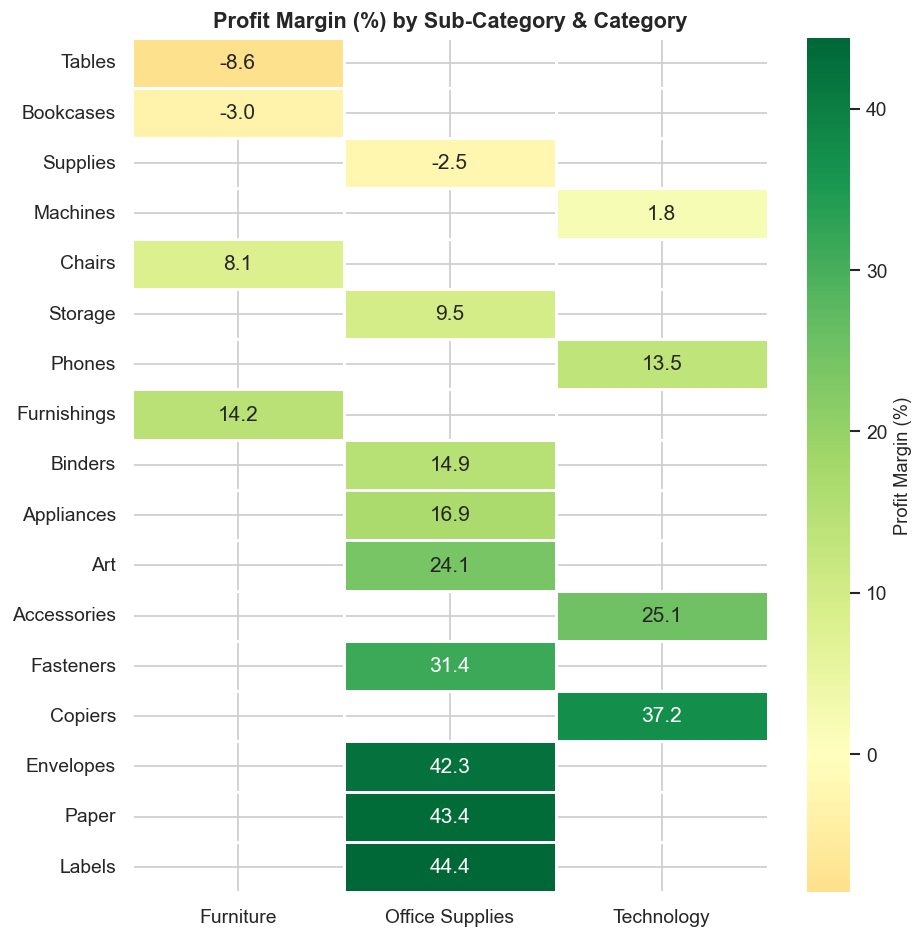

In [45]:
subcat = df.groupby(["Category", "Sub-Category"]).agg(
    total_sales  = ("Sales",  "sum"),
    total_profit = ("Profit", "sum")
).reset_index()
subcat["margin_pct"] = (subcat["total_profit"] / subcat["total_sales"] * 100).round(2)

# Pivot for heatmap
pivot = subcat.pivot(index="Sub-Category", columns="Category", values="margin_pct")
# Sort by average margin
pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            linewidths=0.8, cbar_kws={"label": "Profit Margin (%)"},
            ax=ax, mask=pivot.isnull())
ax.set_title("Profit Margin (%) by Sub-Category & Category")
ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout()
plt.show()


In [46]:

print("\n💡 Insight: Tables and Bookcases are loss-makers. Copiers, Labels, and Paper have the highest margins.")
print("   This heatmap quickly reveals where to focus pricing and discount strategy.")


💡 Insight: Tables and Bookcases are loss-makers. Copiers, Labels, and Paper have the highest margins.
   This heatmap quickly reveals where to focus pricing and discount strategy.


### 2.2  Top 10 Profitable vs Bottom 10 Loss-Making Products

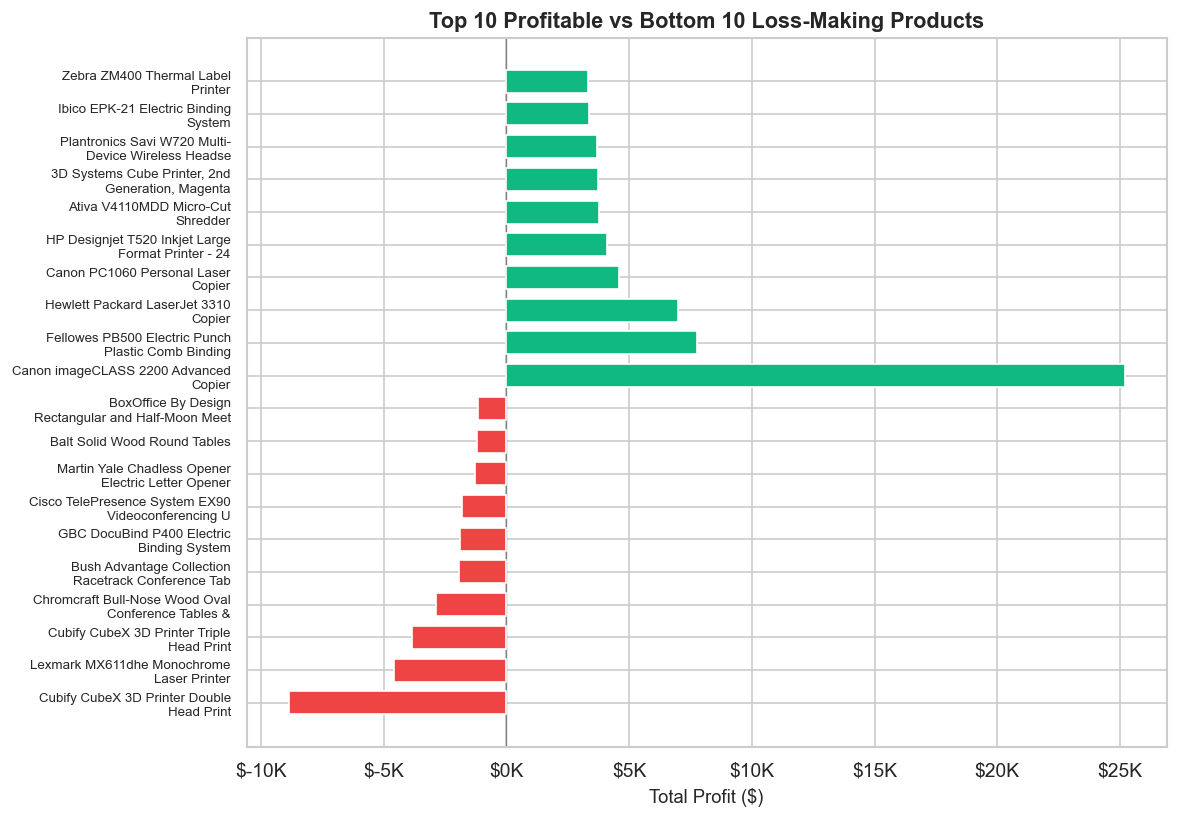

In [47]:
prod_profit = df.groupby("Product Name")["Profit"].sum().reset_index()

top10    = prod_profit.nlargest(10, "Profit")
bottom10 = prod_profit.nsmallest(10, "Profit")
diverging = pd.concat([bottom10, top10]).reset_index(drop=True)
diverging["short_name"] = diverging["Product Name"].apply(lambda x: fill(x[:50], 30))
diverging["color"] = diverging["Profit"].apply(lambda x: PALETTE[1] if x >= 0 else PALETTE[3])

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(diverging)), diverging["Profit"], color=diverging["color"], height=0.7, zorder=3)
ax.set_yticks(range(len(diverging)))
ax.set_yticklabels(diverging["short_name"], fontsize=8)
ax.axvline(0, color="grey", linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
ax.set_title("Top 10 Profitable vs Bottom 10 Loss-Making Products")
ax.set_xlabel("Total Profit ($)")

plt.tight_layout()
plt.show()


In [48]:

print("\n💡 Insight: A handful of products drive outsized profits. The worst loss-makers are mostly")
print("   in Furniture (Tables) and Technology (Machines) — often sold at heavy discounts.")


💡 Insight: A handful of products drive outsized profits. The worst loss-makers are mostly
   in Furniture (Tables) and Technology (Machines) — often sold at heavy discounts.


### 2.3  Discount vs Profit — Scatter Plot

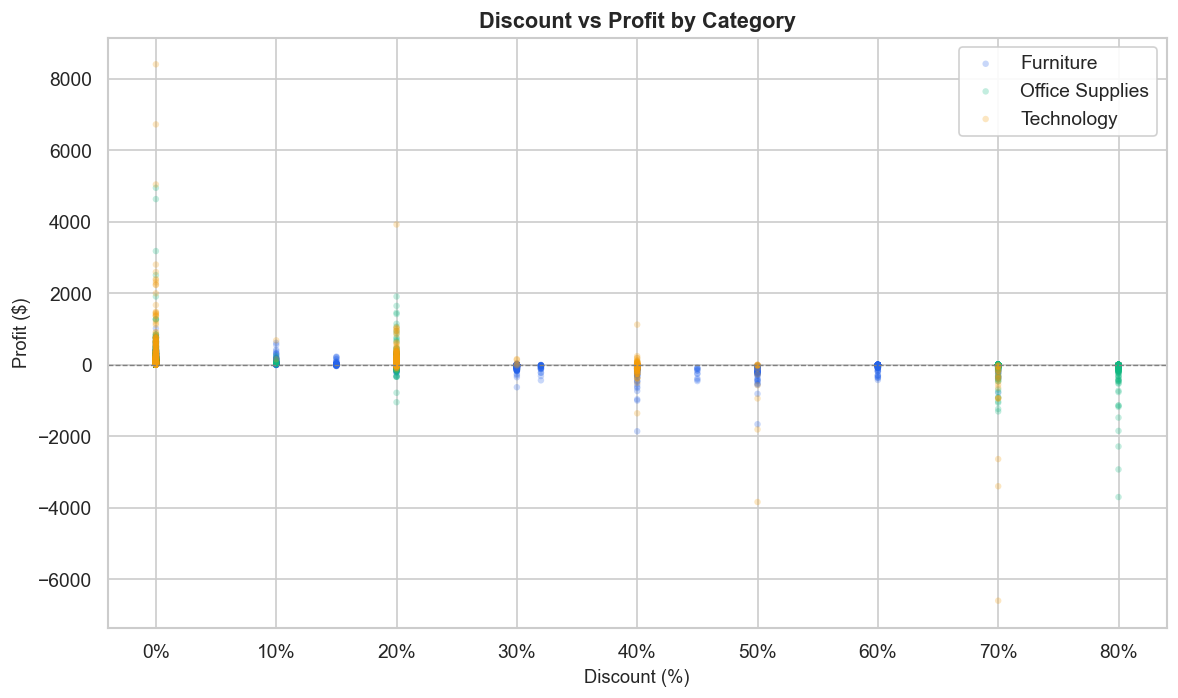

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

cat_colors = {"Furniture": PALETTE[0], "Office Supplies": PALETTE[1], "Technology": PALETTE[2]}

for cat, color in cat_colors.items():
    mask = df["Category"] == cat
    ax.scatter(df.loc[mask, "Discount"], df.loc[mask, "Profit"],
               alpha=0.25, s=15, color=color, label=cat, edgecolors="none")

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Profit ($)")
ax.set_title("Discount vs Profit by Category")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.show()


In [50]:

print("\n💡 Insight: As discount increases, profit plummets — especially beyond 20%.")
print("   Furniture takes the worst hit at high discount levels.")


💡 Insight: As discount increases, profit plummets — especially beyond 20%.
   Furniture takes the worst hit at high discount levels.


### 2.4  Discount Band Impact on Profit

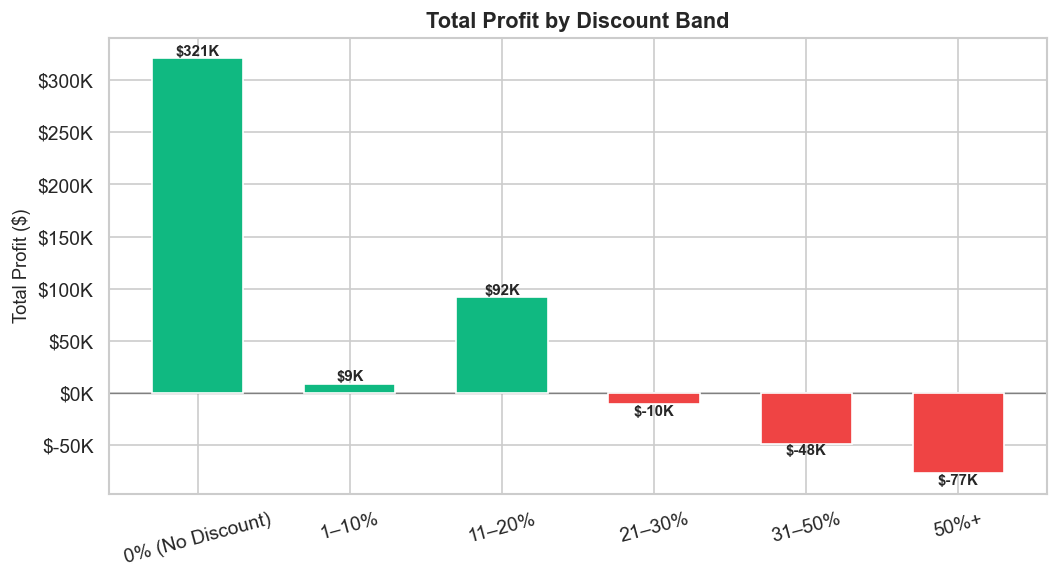

In [51]:
def disc_band(d):
    if d == 0:     return "0% (No Discount)"
    elif d <= 0.10: return "1–10%"
    elif d <= 0.20: return "11–20%"
    elif d <= 0.30: return "21–30%"
    elif d <= 0.50: return "31–50%"
    else:           return "50%+"

df["Discount Band"] = df["Discount"].apply(disc_band)

band_order = ["0% (No Discount)", "1–10%", "11–20%", "21–30%", "31–50%", "50%+"]
band_data = df.groupby("Discount Band").agg(
    total_profit = ("Profit", "sum"),
    avg_profit   = ("Profit", "mean"),
    transactions = ("Profit", "count")
).reindex(band_order).reset_index()

colors = [PALETTE[1] if v >= 0 else PALETTE[3] for v in band_data["total_profit"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(band_data["Discount Band"], band_data["total_profit"], color=colors, zorder=3, width=0.6)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Total Profit by Discount Band")
ax.set_ylabel("Total Profit ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
plt.xticks(rotation=15)

# Add value labels
for i, row in band_data.iterrows():
    va = "bottom" if row["total_profit"] >= 0 else "top"
    ax.text(i, row["total_profit"], f"${row['total_profit']/1000:,.0f}K",
            ha="center", va=va, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()



In [52]:
print("\n💡 Insight: Discounts above 20% consistently destroy profit.")
print("   No-discount transactions generate the bulk of total profit.")


💡 Insight: Discounts above 20% consistently destroy profit.
   No-discount transactions generate the bulk of total profit.


---
## Section 3 — Customer Analytics

### 3.1  Customer Order Frequency Distribution

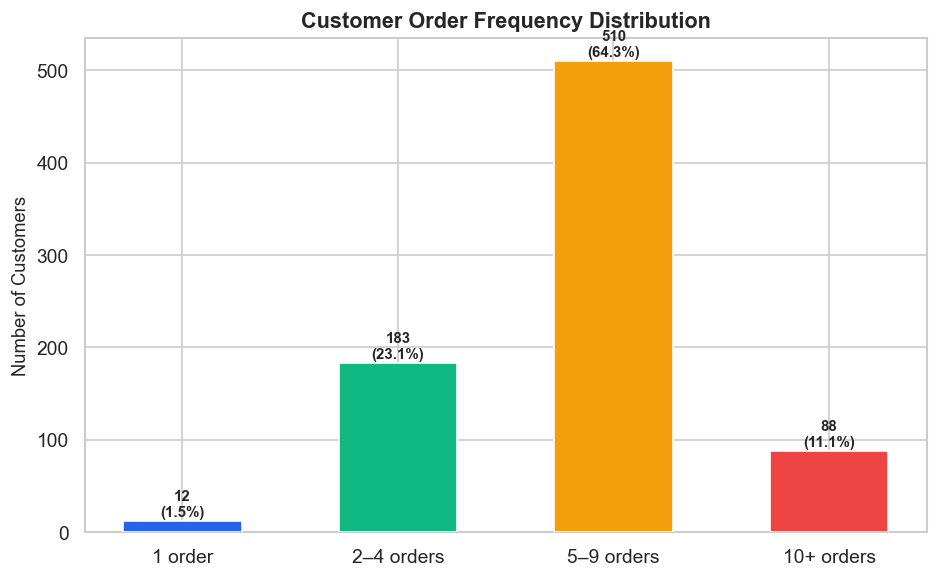

In [53]:
cust_orders = df.groupby("Customer ID")["Order ID"].nunique().reset_index()
cust_orders.columns = ["Customer ID", "order_count"]

def bucket(n):
    if n == 1:       return "1 order"
    elif n <= 4:     return "2–4 orders"
    elif n <= 9:     return "5–9 orders"
    else:            return "10+ orders"

cust_orders["bucket"] = cust_orders["order_count"].apply(bucket)
bucket_order = ["1 order", "2–4 orders", "5–9 orders", "10+ orders"]
bucket_counts = cust_orders["bucket"].value_counts().reindex(bucket_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(bucket_counts.index, bucket_counts.values, color=PALETTE[:4], zorder=3, width=0.55)
ax.set_title("Customer Order Frequency Distribution")
ax.set_ylabel("Number of Customers")

total = bucket_counts.sum()
for bar, val in zip(bars, bucket_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, f"{val}\n({val/total*100:.1f}%)",
            ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()



In [54]:
repeat_pct = (1 - bucket_counts.iloc[0] / total) * 100
print(f"\n💡 Insight: {repeat_pct:.0f}% of customers are repeat buyers (2+ orders).")
print("   This signals strong retention — a good sign for the business.")


💡 Insight: 98% of customers are repeat buyers (2+ orders).
   This signals strong retention — a good sign for the business.


### 3.2  Top 10 Customers by Revenue

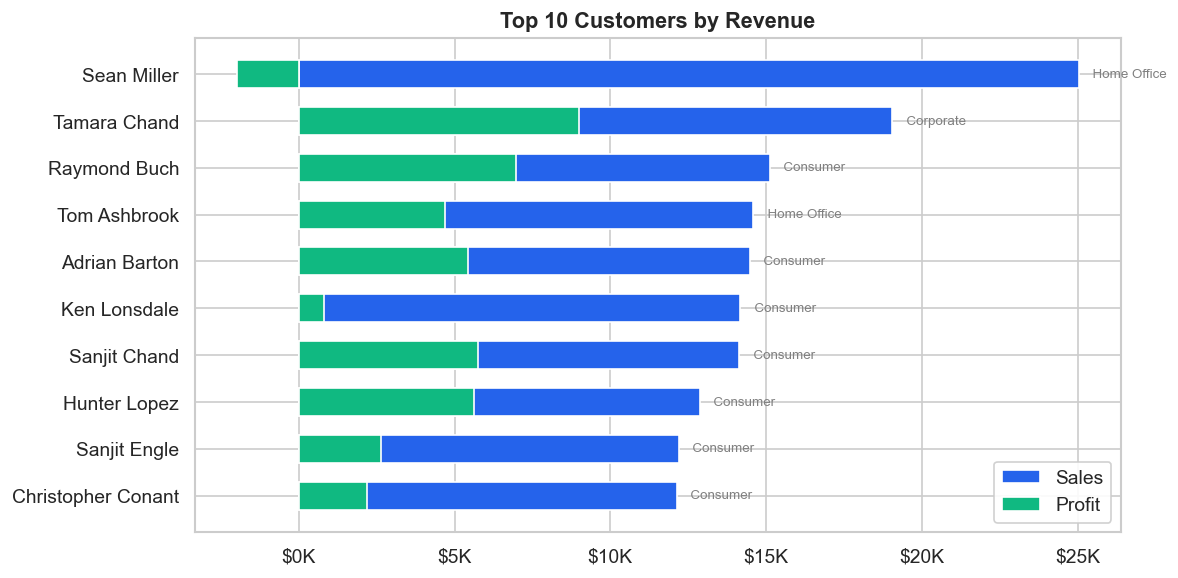

In [55]:
top_cust = df.groupby(["Customer ID", "Customer Name", "Segment"]).agg(
    total_revenue = ("Sales",    "sum"),
    total_profit  = ("Profit",   "sum"),
    total_orders  = ("Order ID", "nunique")
).reset_index().nlargest(10, "total_revenue")

top_cust = top_cust.sort_values("total_revenue", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_cust["Customer Name"], top_cust["total_revenue"],
               color=PALETTE[0], height=0.6, zorder=3)
ax.barh(top_cust["Customer Name"], top_cust["total_profit"],
        color=PALETTE[1], height=0.6, zorder=4, label="Profit")

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
ax.set_title("Top 10 Customers by Revenue")

# Annotate segment
for i, (_, row) in enumerate(top_cust.iterrows()):
    ax.text(row["total_revenue"] + 200, row["Customer Name"],
            f"  {row['Segment']}", va="center", fontsize=8, color="grey")

ax.legend(["Sales", "Profit"], framealpha=0.9)
plt.tight_layout()
plt.show()



In [56]:
print("\n💡 Insight: Top customers span all segments. Some high-revenue customers")
print("   have relatively thin profit margins — worth examining their discount patterns.")


💡 Insight: Top customers span all segments. Some high-revenue customers
   have relatively thin profit margins — worth examining their discount patterns.


---
## Section 4 — Shipping & Operations

### 4.1  Days to Ship Distribution by Ship Mode

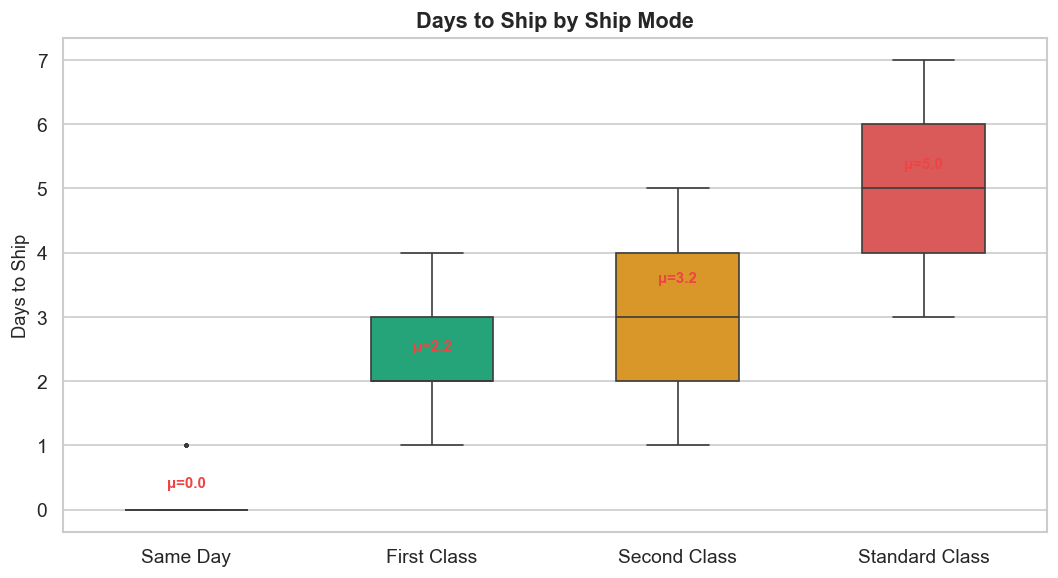

In [57]:
ship_order = ["Same Day", "First Class", "Second Class", "Standard Class"]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="Ship Mode", y="Days_to_Ship", hue="Ship Mode",
            order=ship_order, hue_order=ship_order,
            palette=PALETTE[:4], width=0.5, ax=ax, legend=False,
            flierprops=dict(marker=".", markersize=3, alpha=0.4))
ax.set_title("Days to Ship by Ship Mode")
ax.set_xlabel("")
ax.set_ylabel("Days to Ship")

# Add mean annotations
means = df.groupby("Ship Mode")["Days_to_Ship"].mean().reindex(ship_order)
for i, (mode, mean_val) in enumerate(means.items()):
    ax.text(i, mean_val + 0.3, f"μ={mean_val:.1f}", ha="center", fontsize=9,
            fontweight="bold", color=PALETTE[3])

plt.tight_layout()
plt.show()


In [58]:

print("\n💡 Insight: Ship modes deliver as expected — Same Day averages ~0 days,")
print("   Standard Class averages ~5 days. Tight distributions suggest reliable fulfilment.")


💡 Insight: Ship modes deliver as expected — Same Day averages ~0 days,
   Standard Class averages ~5 days. Tight distributions suggest reliable fulfilment.


---
## Section 5 — Geographic Analytics

### 5.1  Top 10 & Bottom 10 States by Profit

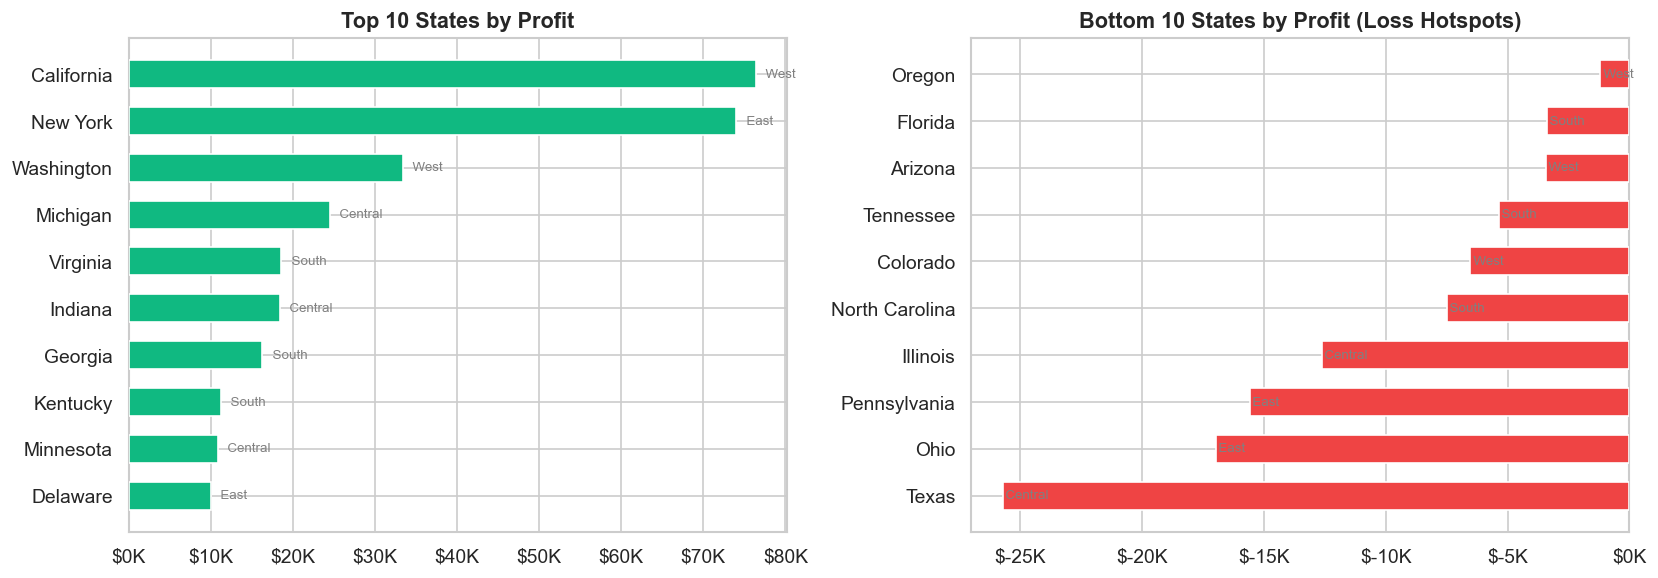

In [59]:
state_profit = df.groupby(["State", "Region"]).agg(
    total_profit = ("Profit", "sum"),
    total_sales  = ("Sales",  "sum")
).reset_index()

top_states    = state_profit.nlargest(10, "total_profit")
bottom_states = state_profit.nsmallest(10, "total_profit")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Top 10
top_sorted = top_states.sort_values("total_profit", ascending=True)
ax1.barh(top_sorted["State"], top_sorted["total_profit"], color=PALETTE[1], height=0.6, zorder=3)
ax1.set_title("Top 10 States by Profit")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
for i, (_, row) in enumerate(top_sorted.iterrows()):
    ax1.text(row["total_profit"] + 300, row["State"], f"  {row['Region']}",
             va="center", fontsize=8, color="grey")

# Bottom 10
bot_sorted = bottom_states.sort_values("total_profit", ascending=True)
ax2.barh(bot_sorted["State"], bot_sorted["total_profit"], color=PALETTE[3], height=0.6, zorder=3)
ax2.set_title("Bottom 10 States by Profit (Loss Hotspots)")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
for i, (_, row) in enumerate(bot_sorted.iterrows()):
    ax2.text(row["total_profit"] - 200, row["State"], f"  {row['Region']}",
             va="center", fontsize=8, color="grey")

plt.tight_layout()
plt.show()


In [60]:

print("\n💡 Insight: California and New York are clear profit leaders (West & East regions).")
print("   Texas, Ohio, and Pennsylvania are the biggest loss hotspots — mostly Central region.")


💡 Insight: California and New York are clear profit leaders (West & East regions).
   Texas, Ohio, and Pennsylvania are the biggest loss hotspots — mostly Central region.


---
## Section 6 — Advanced Analytics (Window Functions)

### 6.1  Cumulative (YTD) Sales by Year

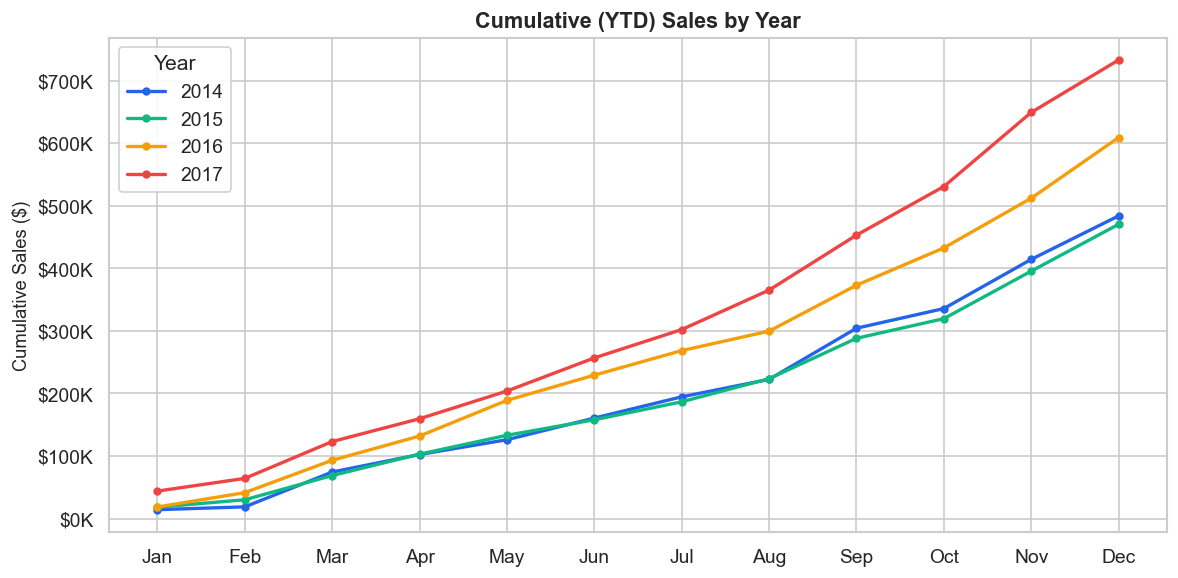

In [61]:
monthly_yr = df.groupby(["Year", df["Order Date"].dt.month]).agg(
    sales = ("Sales", "sum")
).reset_index()
monthly_yr.columns = ["Year", "Month", "sales"]
monthly_yr["ytd_sales"] = monthly_yr.groupby("Year")["sales"].cumsum()

fig, ax = plt.subplots(figsize=(10, 5))

for i, (year, grp) in enumerate(monthly_yr.groupby("Year")):
    ax.plot(grp["Month"], grp["ytd_sales"], marker="o", markersize=4,
            linewidth=2, color=PALETTE[i], label=str(year))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
ax.set_title("Cumulative (YTD) Sales by Year")
ax.set_ylabel("Cumulative Sales ($)")
ax.legend(title="Year", framealpha=0.9)

plt.tight_layout()
plt.show()


In [62]:

print("\n💡 Insight: Each year's curve is above the previous — confirming accelerating growth.")
print("   The steepest climb happens in Q4 (Sep–Dec) every year — holiday seasonality.")


💡 Insight: Each year's curve is above the previous — confirming accelerating growth.
   The steepest climb happens in Q4 (Sep–Dec) every year — holiday seasonality.


### 6.2  Month-over-Month Sales Growth %

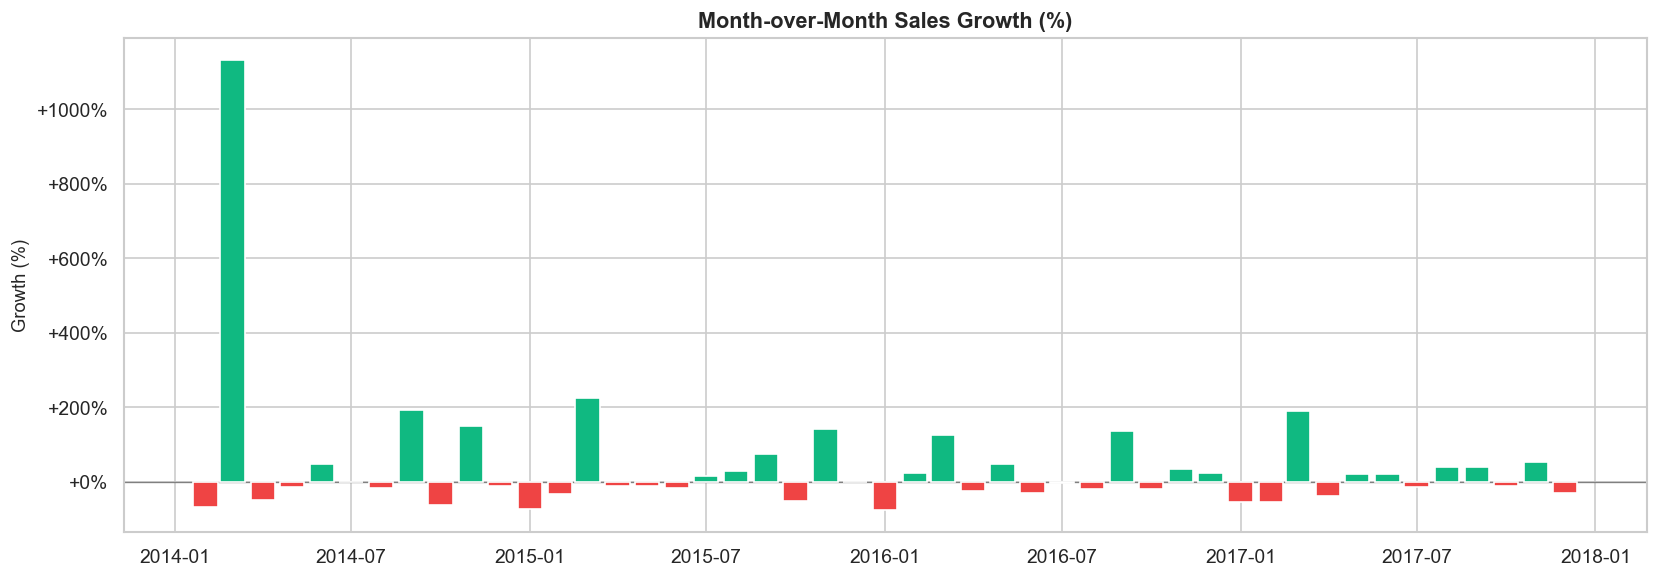

In [63]:
mom = df.groupby("YearMonth")["Sales"].sum().reset_index()
mom.columns = ["YearMonth", "sales"]
mom["prev_sales"] = mom["sales"].shift(1)
mom["growth_pct"] = ((mom["sales"] - mom["prev_sales"]) / mom["prev_sales"] * 100).round(2)
mom = mom.dropna().reset_index(drop=True)
mom["date"] = mom["YearMonth"].dt.to_timestamp()

colors = [PALETTE[1] if g >= 0 else PALETTE[3] for g in mom["growth_pct"]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(mom["date"], mom["growth_pct"], color=colors, width=25, zorder=3)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Month-over-Month Sales Growth (%)")
ax.set_ylabel("Growth (%)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))

plt.tight_layout()
plt.show()

In [64]:


print("\n💡 Insight: Growth is volatile month-to-month, but the positive months outweigh negatives.")
print("   Sharpest drops usually follow holiday peaks (Jan dip after Dec surge).")


💡 Insight: Growth is volatile month-to-month, but the positive months outweigh negatives.
   Sharpest drops usually follow holiday peaks (Jan dip after Dec surge).


---
## Summary of Key Findings

| Finding | Detail |
|:--------|:-------|
| **Steady Growth** | Sales grew every year from 2014 to 2017, with strong Q4 seasonality |
| **Discount Problem** | Discounts above 20% consistently destroy profit — especially in Furniture |
| **Loss-Makers** | Tables and Bookcases are the primary loss-making sub-categories |
| **Regional Gap** | Central region underperforms on profit despite decent sales volume |
| **Strong Retention** | Most customers are repeat buyers (2+ orders) |
| **Copiers Win** | Copiers have the highest profit margin among all sub-categories |
| **State Hotspots** | California & New York lead profit; Texas & Ohio are loss hotspots |